In [2]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import polars as pl
import alphalens as al
import matplotlib.pyplot as plt
from datetime import datetime, time
import calendar

# 配置文件
try:
    import config_local as config
except ImportError:
    import config

# 导入数据接口sdk
import zenidatasdk as zd
client = zd.Client(
    base_url = config.ZENI_URL,
    username = config.ZENI_USERNAME,
    password = config.ZENI_PASSWORD,
)

# 忽视警告信息
warnings.filterwarnings(action = 'ignore')

In [3]:
# 历史回测区间
init_date = '2022-06-01'
start_date = '2022-09-01'
end_date = str(datetime.today().date())
index_symbol = rf"000852.XSHG"

# rf"000300.XSHG",  # 沪深300
# rf"000905.XSHG",  # 中证500
# rf"000852.XSHG",  # 中证1000
# rf"000016.XSHG",  # 上证50
# rf"399006.XSHE",  # 创业板

In [3]:
# 获取指数成分股数据据
index_weights_df = client.get_index_constituents_df(
    index_symbol = index_symbol,
    start_date = start_date,
    end_date = end_date
)
index_weights_df = index_weights_df.rename( columns = {"date": "datetime"} )
symbols = index_weights_df["symbol"].unique().tolist()
index_weights_df

,datetime,index_symbol,update_date,symbol,weight,display_name
0,2020-09-01,000852.XSHG,2020-08-31,000006.XSHE,0.112,深振业A
1,2020-09-01,000852.XSHG,2020-08-31,000011.XSHE,0.079,深物业A
2,2020-09-01,000852.XSHG,2020-08-31,000016.XSHE,0.149,深康佳A
3,2020-09-01,000852.XSHG,2020-08-31,000019.XSHE,0.061,深粮控股
4,2020-09-01,000852.XSHG,2020-08-31,000030.XSHE,0.092,富奥股份
...,...,...,...,...,...,...
1361995,2026-04-17,000852.XSHG,2026-03-31,688776.XSHG,0.055,国光电气
1361996,2026-04-17,000852.XSHG,2026-03-31,688779.XSHG,0.143,五矿新能
1361997,2026-04-17,000852.XSHG,2026-03-31,688789.XSHG,0.084,宏华数科
1361998,2026-04-17,000852.XSHG,2026-03-31,688798.XSHG,0.073,艾为电子


In [4]:
tmp_Dataset_path = rf"D:\tmp_Dataset"
minute_bar_Dataset_path = os.path.join(tmp_Dataset_path, "minute_bar")  # 分钟数据本地路径
os.makedirs(minute_bar_Dataset_path, exist_ok=True)

index_weights_path = os.path.join(minute_bar_Dataset_path, index_symbol)  # 指数成分股
os.makedirs(index_weights_path, exist_ok=True)

In [5]:
def generate_monthly_ranges_dict(start_date, end_date):
    """生成按月切割的日期区间字典，格式为 {YYMM: (月初, 月末)}"""
    start = datetime.strptime(start_date, '%Y-%m-%d').date()
    end = datetime.strptime(end_date, '%Y-%m-%d').date()

    date_dict = {}
    current = start

    while True:
        month_start = current.replace(day=1)
        _, last_day = calendar.monthrange(current.year, current.month)
        month_end = current.replace(day=last_day)

        if month_end > end:  # 不足一个月舍弃
            break

        # 键格式：YYMM（如 2603 表示 2026年03月）
        key = f"{str(current.year)[-2:]}{current.month:02d}"
        date_dict[key] = (month_start.strftime('%Y-%m-%d'), month_end.strftime('%Y-%m-%d'))

        # 移到下个月
        if current.month == 12:
            current = current.replace(year=current.year + 1, month=1, day=1)
        else:
            current = current.replace(month=current.month + 1, day=1)

    return date_dict


date_tuple_list = generate_monthly_ranges_dict(init_date, end_date)
date_tuple_list

{'2006': ('2020-06-01', '2020-06-30'),
 '2007': ('2020-07-01', '2020-07-31'),
 '2008': ('2020-08-01', '2020-08-31'),
 '2009': ('2020-09-01', '2020-09-30'),
 '2010': ('2020-10-01', '2020-10-31'),
 '2011': ('2020-11-01', '2020-11-30'),
 '2012': ('2020-12-01', '2020-12-31'),
 '2101': ('2021-01-01', '2021-01-31'),
 '2102': ('2021-02-01', '2021-02-28'),
 '2103': ('2021-03-01', '2021-03-31'),
 '2104': ('2021-04-01', '2021-04-30'),
 '2105': ('2021-05-01', '2021-05-31'),
 '2106': ('2021-06-01', '2021-06-30'),
 '2107': ('2021-07-01', '2021-07-31'),
 '2108': ('2021-08-01', '2021-08-31'),
 '2109': ('2021-09-01', '2021-09-30'),
 '2110': ('2021-10-01', '2021-10-31'),
 '2111': ('2021-11-01', '2021-11-30'),
 '2112': ('2021-12-01', '2021-12-31'),
 '2201': ('2022-01-01', '2022-01-31'),
 '2202': ('2022-02-01', '2022-02-28'),
 '2203': ('2022-03-01', '2022-03-31'),
 '2204': ('2022-04-01', '2022-04-30'),
 '2205': ('2022-05-01', '2022-05-31'),
 '2206': ('2022-06-01', '2022-06-30'),
 '2207': ('2022-07-01', '

In [6]:
def tmp_filter(dataframe):
    # 1. 临时转换为 datetime 用于过滤
    # 2. 过滤后删除临时列，保留原始字符串
    return (
        dataframe
        .filter(
            (pl.col("datetime").dt.time() <= pl.time(10, 0, 0)) |
            (pl.col("datetime").dt.time() == pl.time(15, 0, 0))
        )
    )

In [7]:
big_minute_bar_dict = {}

from tqdm import tqdm
for month, start_end_tuple in tqdm(
        date_tuple_list.items(), desc = "获取每月分钟数据"
):
    minute_bar_monthly_path = os.path.join(index_weights_path, rf"{month}.parquet")
    if os.path.exists(minute_bar_monthly_path):
        bars_1m_pl_tmp = pl.read_parquet(minute_bar_monthly_path)
    else:
        bars_1m_df_tmp = client.get_kline_df(
            symbol = symbols,
            start_date = start_end_tuple[0],
            end_date = start_end_tuple[1],
            frequency = "1m",
            adjust_type = "post",
            market = "cn_stock",
        )
        bars_1m_pl_tmp = pl.from_pandas(bars_1m_df_tmp)
        bars_1m_pl_tmp.write_parquet(minute_bar_monthly_path, compression = 'snappy')

    # 删除部分数据，减少内存负担 tmp_filter
    if tmp_filter:
        big_minute_bar_dict[month] = tmp_filter(bars_1m_pl_tmp)
    else:
        big_minute_bar_dict[month] = tmp_filter(bars_1m_pl_tmp)
    import gc; gc.collect()


# 分钟数据长表格 bars_1m_df
bars_1m_pl = pl.concat(list(big_minute_bar_dict.values()))
bars_1m_pl.glimpse()
bars_1m_pl.head()

获取每月分钟数据: 100%|██████████| 70/70 [00:09<00:00,  7.34it/s]

Rows: 92255163
Columns: 8
$ open              <f64> 223.27, 222.8, 222.8, 223.27, 223.27, 222.8, 222.34, 222.34, 222.34, 222.34
$ high              <f64> 224.65, 223.27, 223.73, 223.27, 223.27, 223.27, 222.8, 222.8, 222.8, 222.8
$ low               <f64> 222.34, 222.34, 222.34, 222.8, 222.34, 222.8, 222.34, 221.88, 221.88, 222.34
$ close             <f64> 222.34, 223.27, 222.8, 222.8, 222.34, 222.8, 222.8, 222.34, 222.34, 222.34
$ volume            <f64> 9038.95, 3766.77, 4377.19, 1075.29, 1262.11, 1470.65, 182.47, 2045.55, 445.32, 523.53
$ symbol            <str> '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE'
$ amount            <f64> 2020893.0, 839541.0, 977203.0, 239856.0, 281194.0, 327813.0, 40667.0, 454869.0, 99023.0, 116476.0
$ datetime <datetime[ns]> 2020-06-01 09:31:00, 2020-06-01 09:32:00, 2020-06-01 09:33:00, 2020-06-01 09:34:00, 2020-06-01 09:35:00, 2020-06-01 09:36:00, 2020

open,high,low,close,volume,symbol,amount,datetime
f64,f64,f64,f64,f64,str,f64,datetime[ns]
223.27,224.65,222.34,222.34,9038.95,"""000006.XSHE""",2.020893e6,2020-06-01 09:31:00
222.8,223.27,222.34,223.27,3766.77,"""000006.XSHE""",839541.0,2020-06-01 09:32:00
222.8,223.73,222.34,222.8,4377.19,"""000006.XSHE""",977203.0,2020-06-01 09:33:00
223.27,223.27,222.8,222.8,1075.29,"""000006.XSHE""",239856.0,2020-06-01 09:34:00
223.27,223.27,222.34,222.34,1262.11,"""000006.XSHE""",281194.0,2020-06-01 09:35:00


In [4]:
with open(rf"C:\Users\zy\Desktop\2026因子日历\东北证券.pdf"):...

In [8]:
# 本因子是混频算法，需要从高频提取信息用于日频交易
prices_pl = bars_1m_pl.rename(mapping = {"datetime": "datetime_min"})
prices_pl = prices_pl.with_columns(
    pl.col("datetime_min").dt.truncate("1d")    # 截断到天
    .alias("datetime")  # 命名为 datetime。alias 意思是"别名"、"假名"
                        # 在命令 .withcolumns 中表达式若带有 alias 则生成新的列
                        # 否则覆盖原有的列
)

# 多资产价格数据(开盘价买入)
prices_pl = prices_pl.filter( pl.col("datetime") >= pl.lit(datetime.strptime(start_date, "%Y-%m-%d")) )
prices_pl = prices_pl.group_by(['datetime', 'symbol']).agg(
    pl.col('open').first()
) # 取出每一天的第一个价格作为日开盘价
# 注意，Polars 没有 Index 概念，结果始终是 DataFrame，列是扁平的

prices = prices_pl.pivot(index = "datetime", columns = "symbol", values = "open").sort("datetime")
prices = prices.to_pandas().set_index("datetime") # 转化回可被 aplhalens 计算的 pd,dataframe
prices.T.head().T.head()

,603222.XSHG,688321.XSHG,600550.XSHG,300508.XSHE,600814.XSHG
datetime,,,,,
2020-09-01,68.83,49.73,40.09,NaN,NaN
2020-09-02,69.17,48.81,39.55,NaN,NaN
2020-09-03,70.09,47.80,38.79,NaN,NaN
2020-09-04,69.13,47.52,38.41,NaN,NaN
2020-09-07,68.62,48.38,38.56,NaN,NaN


In [9]:
def f_capital_flow_VWAP_estimate_000(
    bars: pl.DataFrame,
    factor_name: str = "capital_flow_VWAP_estimate",
    min_periods: int = 20,
    threshold_quantile: float = 0.2
) -> pl.DataFrame:

    # bars = bars_1m_pl
    # factor_name = "capital_flow_VWAP_estimate"
    # min_periods = 20
    # threshold_quantile = 0.2


    # ========================= 对时间列进行数据类型预处理 =========================
    bars = bars.rename(mapping = {"datetime": "datetime_min"})
    bars = bars.with_columns(
        pl.col('datetime_min').dt.truncate('1d')
        .alias('datetime')
    )

    # ========================= 筛选出 早盘数据 和 每日最后一行数据 =========================
    # 1. 提取早盘数据（9:30:00 - 10:00:59）
    morning_expr = (
        (pl.col('datetime_min').dt.time() <= pl.time(10, 0, 0)) |   # 早盘 10:01 点前的K线
        (pl.col('datetime_min').dt.time() == pl.time(15, 0, 0))     # 每日最后一根K线
    )
    bars = bars.filter(morning_expr)


    # ========================= 计算 VWAP 偏离量以模拟资金流入与流出 =========================
    # 使用 groupby 配合 diff；fillna(0)处理每天第一根K线（9:30无前值）
    bars = bars.with_columns( pl.col("close").shift(1).over("symbol").alias("close_pre") )

    # 用 前分钟收盘价 与 本分钟开盘价 作为基准价格
    bars = bars.with_columns( ((pl.col("close_pre") + pl.col("open")) / 2).alias("benchmark_price") )

    # 用于辅助判断的价格变动列
    bars = bars.with_columns( (pl.col("close") - pl.col("benchmark_price")).alias('price_diff') )

    # 计算成交量加权的价格重心
    bars = bars.with_columns( (pl.col('amount') / pl.col('volume')).alias('VWAP') )

    # 用 VWAP 即交易重心偏离 上一分钟末 与 参考基准价 的价格的程度来代理资金的流向
    bars = bars.with_columns( (pl.col('VWAP') - pl.col('benchmark_price')).alias('VWAP_bias') )

    # 计算出这一视角下，资金流动的具体额度
    bars = bars.with_columns( (pl.col('VWAP_bias') / pl.col('VWAP') * pl.col('amount')).alias('capital_flow_VWAP_estimate') )
    # 如果资金想入场，则通常愿意接受稍高的价格以持有
    # 如果资金想离场，则通常愿意接受稍低价出手


    # ========================= 制作为日频表 =========================
    # ========================= 计算早盘震荡程度值 =========================
    bars = bars.with_columns( pl.col("close").last().over("symbol").alias("close_daily") ) # 定义每日收盘价字段
    bars = bars.filter( pl.col('datetime_min').dt.time() <= pl.time(10, 0, 0) )

    bars = bars.sort(["symbol", "datetime"])
    bars = bars.group_by(["symbol", "datetime"]).agg(
        pl.col("open").first().alias("open"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("close_daily").last().alias("close_daily"),
        pl.col("capital_flow_VWAP_estimate").sum().alias("capital_flow_VWAP_estimate")
    )
    bars = bars.with_columns(
        ((pl.col('high') - pl.col('low')) / (pl.col('open') + pl.col("close_daily")))
        .alias("fluctuation")
    )


    # ========================= 滚动窗口计算每个时间点上 过去一个月的聚合值 =========================
    bars = bars.sort(["symbol", "datetime"])
    bars = bars.with_columns(
        pl.col("fluctuation").rolling_sum(window_size = min_periods)
        .over("symbol"),

        pl.col("capital_flow_VWAP_estimate").rolling_sum(window_size = min_periods)
        .over("symbol")
    )


    # ========================= 去除每天 fluctuation 前指定分位的行 =========================
    bars = (

        # 1. 按 datetime 分组，组内按 fluctuation 降序排名
        bars.with_columns(
            pl.col("fluctuation")
            .rank(descending = True)  # 排名最大的 = 1，最小的 = N
            .over("datetime")
            .alias("rank_desc")
        )

        # 2. 计算每组的大小，保留排名靠后的
        .with_columns(
            pl.count().over("datetime").alias("group_size")
        )

        # 3. 过滤，只保留排名 > threshold_idx 的行
        .filter(
            pl.col("rank_desc") > (pl.col("group_size") * threshold_quantile)
        )

        # 4. 重命名
        .rename({"capital_flow_VWAP_estimate": "factor_value"})
        .with_columns(
            pl.lit(factor_name).alias("factor_name"),
            pl.col("datetime").cast(pl.Datetime("ns"))  # 确保时间类型
        )
    )

    bars = bars.sort(["symbol", "datetime"])
    return bars.select(["datetime", "symbol", "factor_name", "factor_value"])

In [ ]:
factors_pl = f_capital_flow_VWAP_estimate_000(
    bars = bars_1m_pl,
    factor_name = "capital_flow_VWAP_estimate",
    min_periods = 20,
    threshold_quantile = 0.2,
)
factors_pl

In [21]:
# 因子值 shift 1 转换成实际使用时间 (T+1)
factors_pl = factors_pl.with_columns( pl.col("factor_name").shift(1).over("symbol") )

# 转化为可用于 alphalens 计算的 pd.dataframe
factors_df = factors_pl.to_pandas()

# 与指数的交易日历、历史成分股数据对齐
factors_df = pd.merge(index_weights_df[["datetime", "symbol"]], factors_df, how = "left", on = ["datetime", "symbol"])

# 转换成[datetime, symbol]双重索引的factor_table
factors = factors_df.pivot_table(index = ["datetime", "symbol"], columns = "factor_name", values = "factor_value")
factors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 107902 entries, (Timestamp('2025-09-01 00:00:00'), '000012.XSHE') to (Timestamp('2026-03-31 00:00:00'), '002046.XSHE')
Data columns (total 1 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   capital_flow_VWAP_estimate  107902 non-null  float64
dtypes: float64(1)
memory usage: 1.2+ MB


In [22]:
# 调用alphalens进行数据清洗
factor_data = al.utils.get_clean_factor_and_forward_returns(
    factor=factors,
    prices=prices,
    periods=(1, 5, 20),
    bins=None,
    quantiles=7,
    groupby=None,
    groupby_labels=None,
    binning_by_group=False,
    filter_zscore=20,
    max_loss=0.25,
    zero_aware=False,
    cumulative_returns=True
)
factor_data

Dropped 14.2% entries from factor data: 14.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 25.0%, not exceeded: OK!


1D        5D       20D        factor  \
date       asset                                                     
2025-09-01 000012.XSHE  0.002132  0.012679 -0.018903 -3.259127e+04   
           000019.XSHE -0.005789 -0.027388 -0.061679 -4.679890e+04   
           000025.XSHE  0.007823  0.023470 -0.036108 -2.027360e+05   
           000028.XSHE -0.000409 -0.010834 -0.034410  5.276059e+04   
           000030.XSHE -0.013754 -0.029126 -0.032767  2.660266e+04   
...                          ...       ...       ...           ...   
2026-03-03 688068.XSHG -0.010348  0.065791 -0.002384  2.769153e+05   
           301004.XSHE -0.014296 -0.106796 -0.213912  6.040350e+05   
           603262.XSHG -0.024705 -0.014381 -0.085546 -1.137240e+04   
           688486.XSHG -0.090711 -0.092360 -0.250363 -7.915244e+04   
           600686.XSHG -0.078834 -0.024716  0.014403 -1.315604e+06   

                        factor_quantile  
date       asset                         
2025-09-01 000012.XSHE                2  
           000019.XSHE                2  
           000025.XSHE                1  
           000028.XSHE                3  
           000030.XSHE                2  
...                                 ...  
2026-03-03 688068.XSHG                5  
           301004.XSHE                6  
           603262.XSHG                4  
           688486.XSHG                3  
           600686.XSHG                1  

[92563 rows x 5 columns]

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-6.903185e+07,-5.769256e+04,-1.569903e+06,3.271445e+06,13271,14.337262
2,-9.993719e+05,6.033199e+04,-2.123549e+05,1.728948e+05,13206,14.267040
3,-3.958775e+05,2.186959e+05,-4.687790e+04,9.877798e+04,13209,14.270281
4,-1.491224e+05,5.533962e+05,8.442319e+04,1.308752e+05,13204,14.264879
5,-1.095629e+04,1.244806e+06,3.270063e+05,2.481763e+05,13197,14.257317
6,1.999636e+05,2.950176e+06,9.678439e+05,5.049174e+05,13218,14.280004
7,8.112333e+05,1.704671e+08,6.516739e+06,9.548522e+06,13258,14.323218


Returns Analysis


,1D,5D,20D
Ann. alpha,1.244,0.509,0.453
beta,0.916,0.853,0.935
Mean Period Wise Return Top Quantile (bps),48.290,33.258,25.840
Mean Period Wise Return Bottom Quantile (bps),-13.860,6.923,6.376
Mean Period Wise Spread (bps),62.149,26.151,19.264


<Figure size 640x480 with 0 Axes>

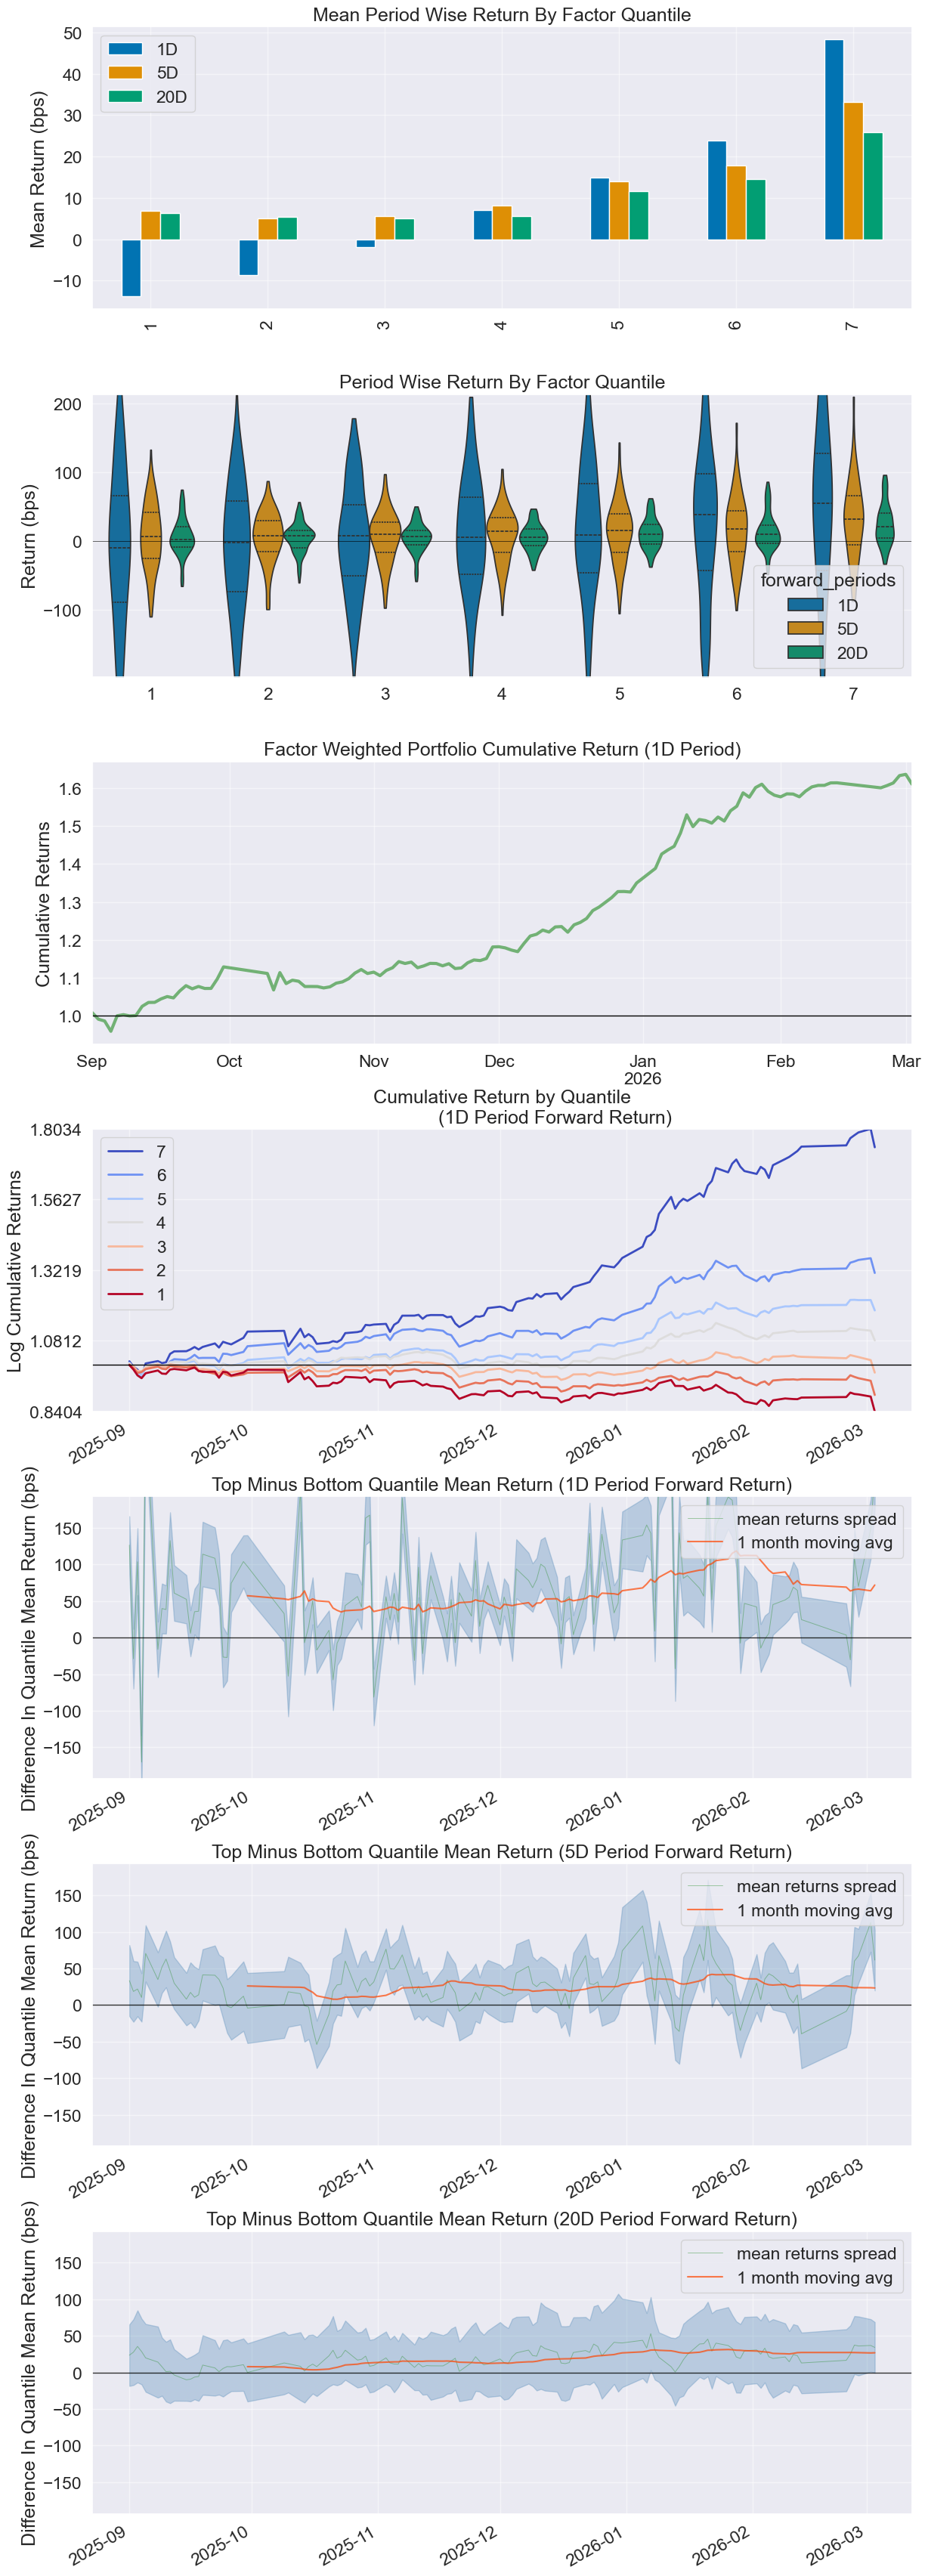

Information Analysis


,1D,5D,20D
IC Mean,0.049,0.038,0.048
IC Std.,0.100,0.096,0.091
Risk-Adjusted IC,0.489,0.394,0.528
t-stat(IC),5.315,4.280,5.741
p-value(IC),0.000,0.000,0.000
IC Skew,0.005,0.161,-0.585
IC Kurtosis,1.073,-0.079,0.202


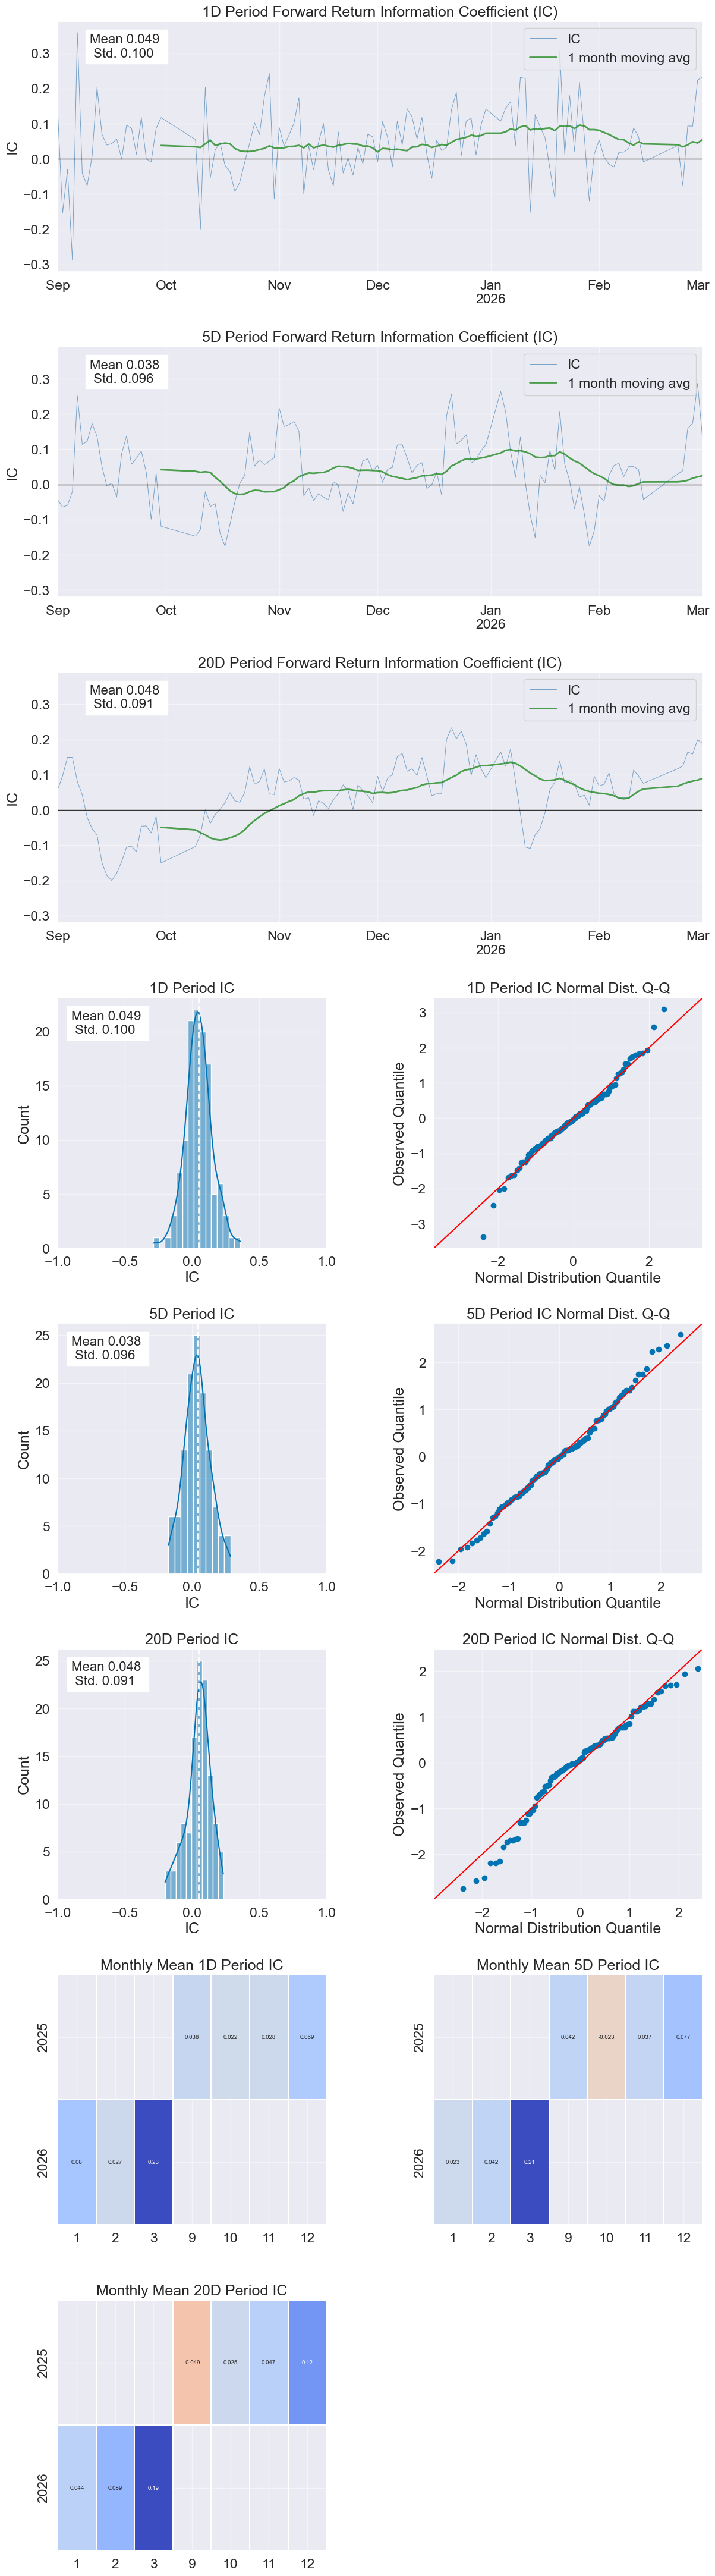

Turnover Analysis


,1D,5D,20D
Quantile 1 Mean Turnover,0.177,0.451,0.862
Quantile 2 Mean Turnover,0.284,0.579,0.858
Quantile 3 Mean Turnover,0.314,0.605,0.815
Quantile 4 Mean Turnover,0.313,0.598,0.826
Quantile 5 Mean Turnover,0.290,0.597,0.860
Quantile 6 Mean Turnover,0.226,0.523,0.865
Quantile 7 Mean Turnover,0.136,0.401,0.824


,1D,5D,20D
Mean Factor Rank Autocorrelation,0.913,0.669,0.041


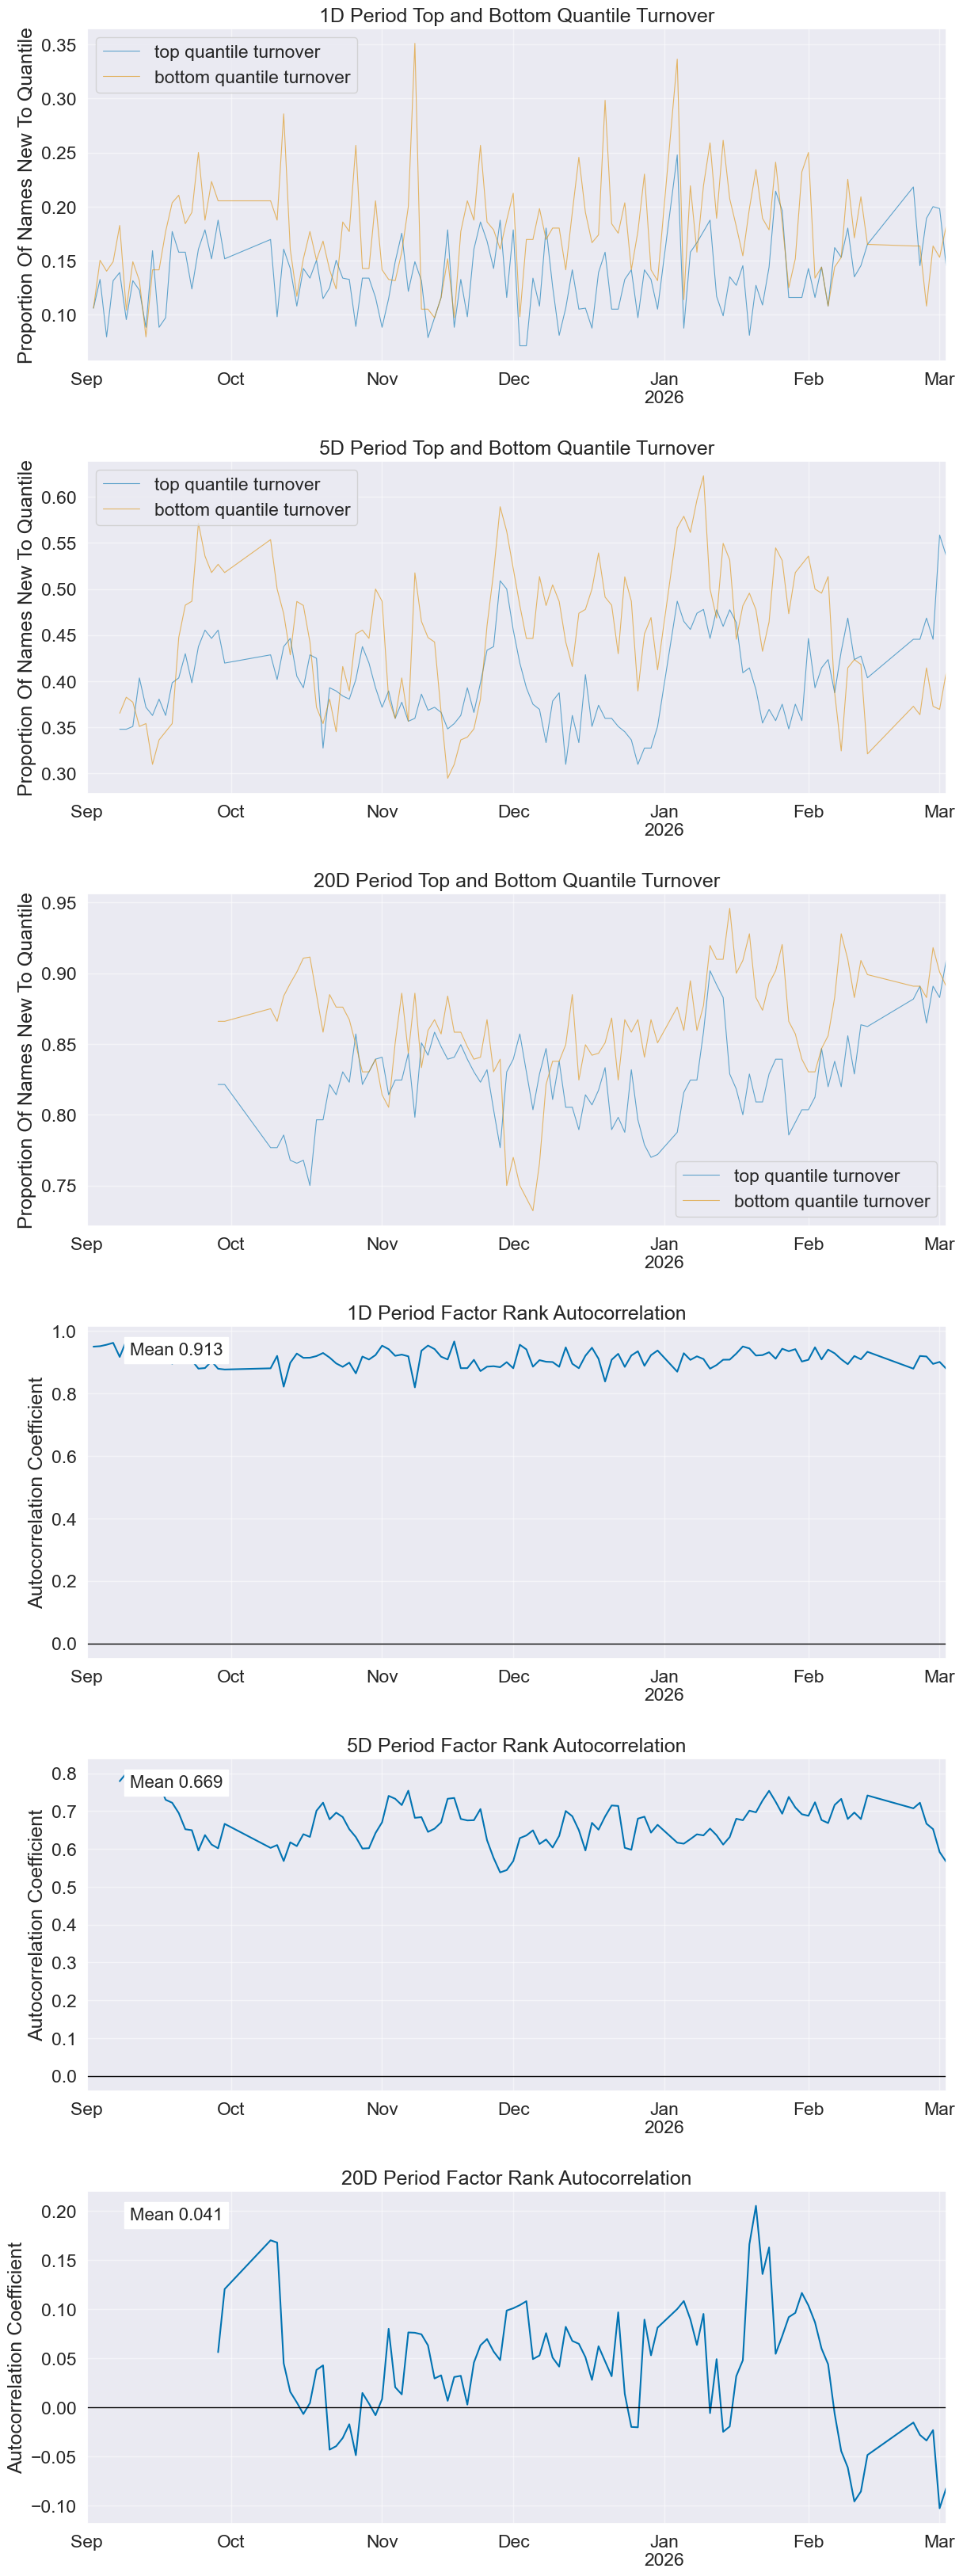

In [23]:
# 调用alphalens进行因子评估
al.tears.create_full_tear_sheet(
    factor_data=factor_data,
    long_short=False,
    group_neutral=False,
    by_group=False
)